In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import config
from src import *

# **1. Download data**

In [2]:
tickers = config.tickers
data = DataLoader(tickers)
data.download_data(start_date = config.start_date, end_date = config.end_date)

[*********************100%***********************]  100 of 100 completed


Price        Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2010-01-04    6.418383         NaN   18.321980   37.090000   25.670000   
2010-01-05    6.429478         NaN   18.173944   37.700001   25.280001   
2010-01-06    6.327211         NaN   18.274879   37.619999   25.340000   
2010-01-07    6.315512         NaN   18.426270   36.889999   25.480000   
2010-01-08    6.357500         NaN   18.520464   36.689999   26.260000   
...                ...         ...         ...         ...         ...   
2025-10-06  256.441406  226.718307  132.476868  350.140015  323.429993   
2025-10-07  256.231628  229.318481  131.763657  348.309998  314.190002   
2025-10-08  257.810089  227.752457  133.001862  348.769989  311.410004   
2025-10-09  253.793961  227.210754  132.050919  347.470001  310.320007   
2025-10-10  245.032471  227.023605  131.317917  337.510010  303.500000   

Price                                                                    ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2010-01-04    9.700000   39.311680    6.695000   51.433239    32.425724  ...   
2010-01-05    9.710000   38.971138    6.734500   51.006474    32.678310  ...   
2010-01-06    9.570000   38.678280    6.612500   50.585899    32.977692  ...   
2010-01-07    9.470000   38.324112    6.500000   50.295204    32.060860  ...   
2010-01-08    9.430000   38.664654    6.676000   50.616821    31.293711  ...   
...                ...         ...         ...         ...          ...  ...   
2025-10-06  203.710007  292.037079  220.899994  268.986603  1041.452271  ...   
2025-10-07  211.509995  293.447021  221.779999  268.927032  1000.524902  ...   
2025-10-08  235.559998  292.533539  225.220001  266.633759   986.060547  ...   
2025-10-09  232.889999  293.337799  227.740005  260.806305   978.803406  ...   
2025-10-10  214.899994  288.075348  216.369995  255.217087   934.531982  ...   

Price           Volume                                                   \
Ticker            UBER       UL       UNH       UPS         V       WFC   
Date                                                                      
2010-01-04         NaN   709690  12199500   3897200  20180000  39335700   
2010-01-05         NaN   825396  11180700   5966300  25833600  55416000   
2010-01-06         NaN  1608701   9761100   5770200  16254000  33237000   
2010-01-07         NaN  1212386  11789800   5747000  27841200  61649000   
2010-01-08         NaN   676390   7228700  13779300  11907200  35508700   
...                ...      ...       ...       ...       ...       ...   
2025-10-06  22760900.0  1801397   7181700   6987000   4735600  12837700   
2025-10-07  12583600.0  1941701   7236200   4726800   5044600  10371300   
2025-10-08  10071200.0  1617314   9438300   4896000   3927500  11277400   
2025-10-09  13435700.0  2237760   8759800   5784700   4434800   8432200   
2025-10-10  17021100.0  4715990  13141900   8506000   6296200  16004300   

Price                                               
Ticker           WMT       XOM        XYZ      YUM  
Date                                                
2010-01-04  62259300  27809100        NaN  2962274  
2010-01-05  46945200  30174700        NaN  3298757  
2010-01-06  37551600  35044700        NaN  4178981  
2010-01-07  31988100  27192100        NaN  2452472  
2010-01-08  34089600  24891800        NaN  3772392  
...              ...       ...        ...      ...  
2025-10-06  13303600  12036800  5324100.0  1395000  
2025-10-07  15538900  11945000  5428000.0  1657100  
2025-10-08  13584100  12301000  6024900.0  1150600  
2025-10-09  19508000  10976200  4193600.0  1371000  
2025-10-10  18519400  13811600  8802300.0  2055300  

[3968 rows x 600 columns]

In [3]:
data.save_df(filename='price_volume_data.csv')

# **2. Data Preparation and Oulier Handling**

In [2]:
from src.data.data_processor import DataProcessor

In [3]:
data = pd.read_csv("price_volume_data.csv", header=[0, 1], index_col=0, parse_dates=True)
data.head()

Price      Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418384  NaN  18.321972  37.090000  25.670000  9.70  39.311672   
2010-01-05  6.429481  NaN  18.173946  37.700001  25.280001  9.71  38.971142   
2010-01-06  6.327209  NaN  18.274872  37.619999  25.340000  9.57  38.678288   
2010-01-07  6.315513  NaN  18.426270  36.889999  25.480000  9.47  38.324123   
2010-01-08  6.357502  NaN  18.520473  36.689999  26.260000  9.43  38.664658   

Price                                     ... Volume                     \
Ticker        AMZN        APD       ASML  ...   UBER       UL       UNH   
Date                                      ...                             
2010-01-04  6.6950  51.433224  32.425720  ...    NaN   709690  12199500   
2010-01-05  6.7345  51.006466  32.678326  ...    NaN   825396  11180700   
2010-01-06  6.6125  50.585896  32.977688  ...    NaN  1608701   9761100   
2010-01-07  6.5000  50.295197  32.060871  ...    NaN  1212386  11789800   
2010-01-08  6.6760  50.616817  31.293734  ...    NaN   676390   7228700   

Price                                                                      
Ticker           UPS         V       WFC       WMT       XOM XYZ      YUM  
Date                                                                       
2010-01-04   3897200  20180000  39335700  62259300  27809100 NaN  2962274  
2010-01-05   5966300  25833600  55416000  46945200  30174700 NaN  3298757  
2010-01-06   5770200  16254000  33237000  37551600  35044700 NaN  4178981  
2010-01-07   5747000  27841200  61649000  31988100  27192100 NaN  2452472  
2010-01-08  13779300  11907200  35508700  34089600  24891800 NaN  3772392  

[5 rows x 600 columns]

In [4]:
processor = DataProcessor("price_volume_data.csv")

df = processor.process()
df.head()

Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418384  NaN  18.321972  37.090000  25.670000  9.70  39.311672   
2010-01-05  6.429481  NaN  18.173946  37.700001  25.280001  9.71  38.971142   
2010-01-06  6.327209  NaN  18.274872  37.619999  25.340000  9.57  38.678288   
2010-01-07  6.315513  NaN  18.426270  36.889999  25.480000  9.47  38.324123   
2010-01-08  6.357502  NaN  18.520473  36.689999  26.260000  9.43  38.664658   

                                          ... Log Return                      \
Ticker        AMZN        APD       ASML  ...       UBER        UL       UNH   
Date                                      ...                                  
2010-01-04  6.6950  51.433224  32.425720  ...        NaN       NaN       NaN   
2010-01-05  6.7345  51.006466  32.678326  ...        NaN -0.022035 -0.001587   
2010-01-06  6.6125  50.585896  32.977688  ...        NaN -0.005425  0.009799   
2010-01-07  6.5000  50.295197  32.060871  ...        NaN -0.007065  0.037659   
2010-01-08  6.6760  50.616817  31.293734  ...        NaN  0.004822 -0.009435   

                                                                            
Ticker           UPS         V       WFC       WMT       XOM XYZ       YUM  
Date                                                                        
2010-01-04       NaN       NaN       NaN       NaN       NaN NaN       NaN  
2010-01-05  0.001717 -0.011526  0.027083 -0.010008  0.003897 NaN -0.003426  
2010-01-06 -0.007406 -0.013519  0.001423 -0.002237  0.008606 NaN -0.007175  
2010-01-07 -0.007635  0.009264  0.035643  0.000560 -0.003147 NaN -0.000288  
2010-01-08  0.037015  0.002763 -0.009312 -0.005050 -0.004020 NaN  0.000288  

[5 rows x 700 columns]

In [5]:
c = Calculate("cleaned_price_volume_data.csv")
c.add_indicators()

c.df.to_csv("price_volume_indicators_data.csv")

# c.calculate_position_size()

print(set(c.df.columns.get_level_values(0)))
c.df.tail()

{'Volume', 'Low', 'Volatility', 'High', 'Adj Close', 'Close', 'Log Return', 'SMA_50', 'SMA_200', 'Open'}


Adj Close                                                  \
Ticker            AAPL        ABBV         ABT        ADBE        ADSK   
Date                                                                     
2025-10-06  256.441406  226.718292  132.476868  350.140015  323.429993   
2025-10-07  256.231628  229.318466  131.763672  348.309998  314.190002   
2025-10-08  257.810089  227.752457  133.001862  348.769989  311.410004   
2025-10-09  253.793961  227.210754  132.050919  347.470001  310.320007   
2025-10-10  245.032471  227.023605  131.317917  337.510010  303.500000   

                                                                         ...  \
Ticker             AMD        AMGN        AMZN         APD         ASML  ...   
Date                                                                     ...   
2025-10-06  203.710007  292.037079  220.899994  268.986603  1041.452271  ...   
2025-10-07  211.509995  293.447021  221.779999  268.927032  1000.524902  ...   
2025-10-08  235.559998  292.533539  225.220001  266.633759   986.060547  ...   
2025-10-09  232.889999  293.337799  227.740005  260.806305   978.803406  ...   
2025-10-10  214.899994  288.075348  216.369995  255.217087   934.531982  ...   

           Volatility                                                    \
Ticker           UBER        UL       UNH       UPS         V       WFC   
Date                                                                      
2025-10-06   0.340511  0.114900  0.251534  0.158889  0.187511  0.184932   
2025-10-07   0.332844  0.116157  0.250673  0.158124  0.189085  0.185560   
2025-10-08   0.334374  0.110914  0.207018  0.158309  0.189213  0.182772   
2025-10-09   0.352972  0.114522  0.208329  0.162004  0.184012  0.182012   
2025-10-10   0.365892  0.142903  0.240623  0.188054  0.179868  0.201537   

                                                    
Ticker           WMT       XOM       XYZ       YUM  
Date                                                
2025-10-06  0.145096  0.191584  0.329469  0.199246  
2025-10-07  0.133365  0.191213  0.331345  0.189073  
2025-10-08  0.133994  0.190642  0.340763  0.182260  
2025-10-09  0.122750  0.186059  0.327480  0.199029  
2025-10-10  0.094926  0.197964  0.437527  0.182778  

[5 rows x 1000 columns]

## **3. EDA**

In [9]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [10]:
from src.plot import EDAPlots

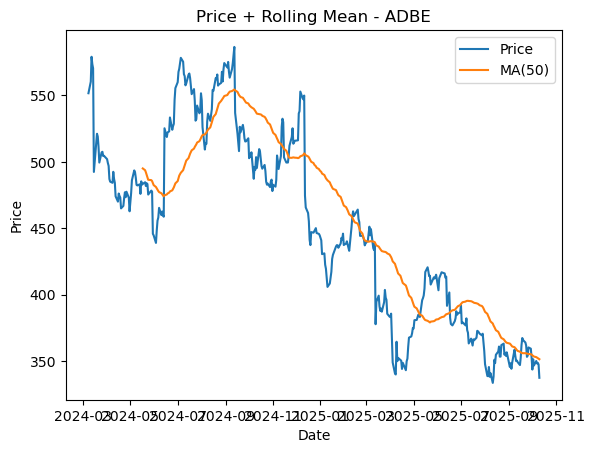

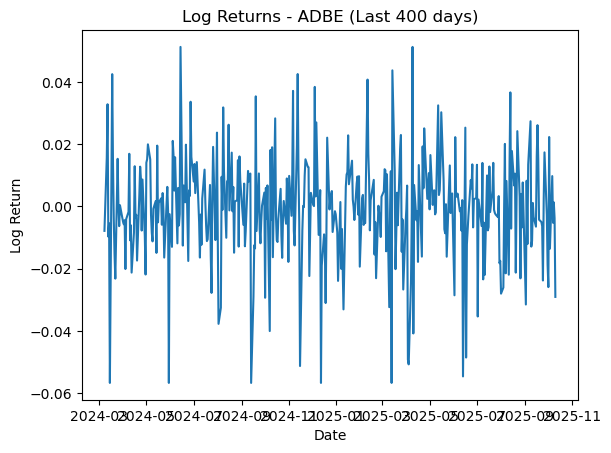

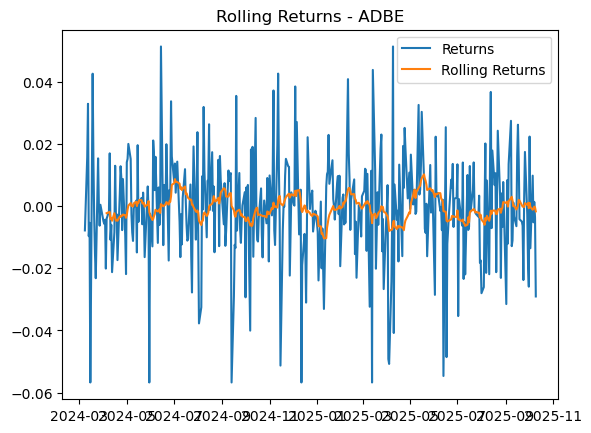

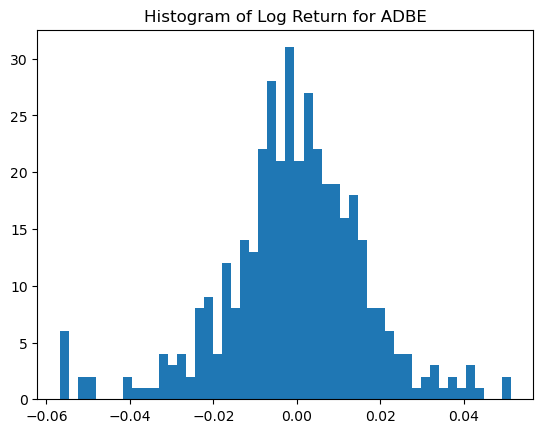

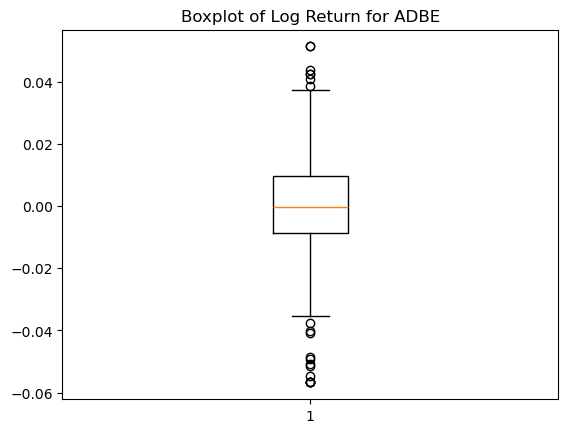

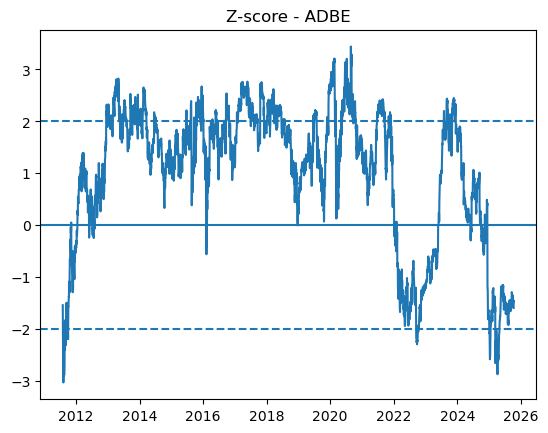

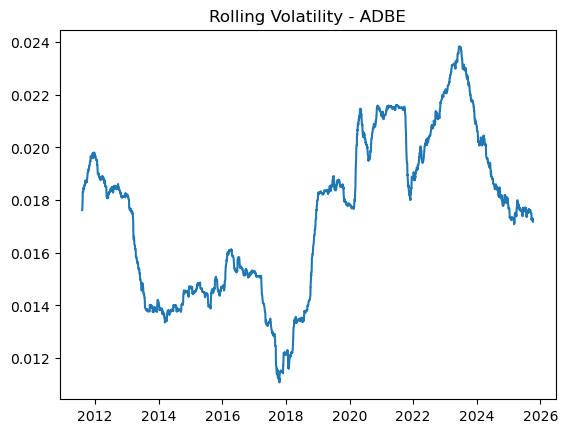

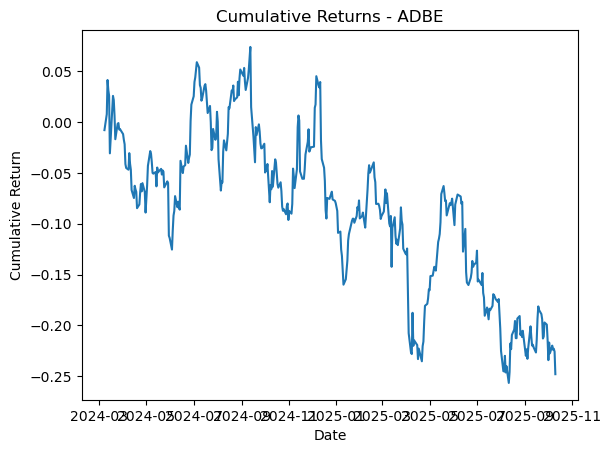

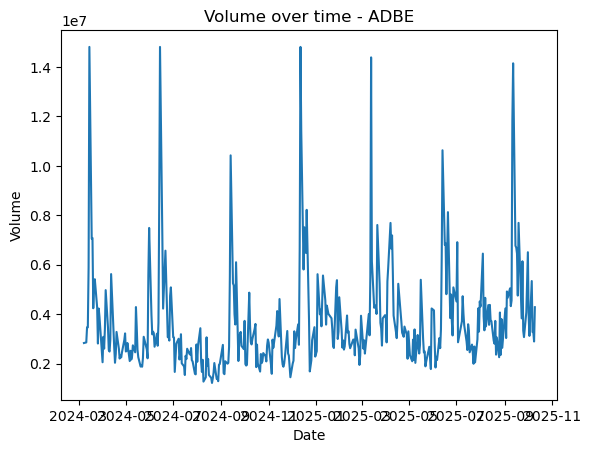

In [12]:
# Xet ticker ADBE

eda = EDAPlots()
ticker = "ADBE"
days = 400

eda.plot_price_with_rolling_mean(df, ticker, 50, days)
eda.plot_returns(df, ticker, days)
eda.plot_rolling_returns(df, ticker, 20, days)
eda.draw_histogram(df, ticker, "Log Return", days)
eda.draw_boxplot(df, ticker, "Log Return", days)
eda.plot_zscore(df, ticker, days)
eda.plot_rolling_volatility(df, ticker, days)
eda.plot_cumulative_returns(df, ticker, days)
eda.plot_volume(df, ticker, days)


# **3. Trading Strategy**

In [13]:
df = pd.read_csv("price_volume_indicators_data.csv", header=[0, 1], index_col=0, parse_dates=True)
print(set(df.columns.get_level_values(0)))

{'Volume', 'Low', 'Volatility', 'High', 'Adj Close', 'Close', 'Log Return', 'SMA_50', 'SMA_200', 'Open'}


In [14]:
df.head()

Adj Close                                                         \
Ticker          AAPL ABBV        ABT       ADBE       ADSK   AMD       AMGN   
Date                                                                          
2010-01-04  6.418384  NaN  18.321972  37.090000  25.670000  9.70  39.311672   
2010-01-05  6.429481  NaN  18.173946  37.700001  25.280001  9.71  38.971142   
2010-01-06  6.327209  NaN  18.274872  37.619999  25.340000  9.57  38.678288   
2010-01-07  6.315513  NaN  18.426270  36.889999  25.480000  9.47  38.324123   
2010-01-08  6.357502  NaN  18.520473  36.689999  26.260000  9.43  38.664658   

                                          ... Volatility                      \
Ticker        AMZN        APD       ASML  ...       UBER  UL UNH UPS   V WFC   
Date                                      ...                                  
2010-01-04  6.6950  51.433224  32.425720  ...        NaN NaN NaN NaN NaN NaN   
2010-01-05  6.7345  51.006466  32.678326  ...        NaN NaN NaN NaN NaN NaN   
2010-01-06  6.6125  50.585896  32.977688  ...        NaN NaN NaN NaN NaN NaN   
2010-01-07  6.5000  50.295197  32.060871  ...        NaN NaN NaN NaN NaN NaN   
2010-01-08  6.6760  50.616817  31.293734  ...        NaN NaN NaN NaN NaN NaN   

                            
Ticker     WMT XOM XYZ YUM  
Date                        
2010-01-04 NaN NaN NaN NaN  
2010-01-05 NaN NaN NaN NaN  
2010-01-06 NaN NaN NaN NaN  
2010-01-07 NaN NaN NaN NaN  
2010-01-08 NaN NaN NaN NaN  

[5 rows x 1000 columns]

## **3.1. Momentum Strategy**

In [15]:
momentum = MomentumStrategy(df)
momentum_signals = momentum.generate_signals()
momentum_signals.tail()

Signal                                               ...            \
Ticker       AAPL ABBV  ABT ADBE ADSK  AMD AMGN AMZN  APD ASML  ... UBER   UL   
Date                                                            ...             
2025-10-06    1.0  1.0  1.0 -1.0  1.0  0.0  1.0 -1.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-07    1.0  1.0  1.0 -1.0  1.0  1.0  1.0 -1.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-08    1.0  1.0  1.0 -1.0  1.0  1.0  1.0 -1.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-09    1.0  1.0  1.0 -1.0  1.0  1.0  1.0  0.0 -1.0  1.0  ...  1.0 -1.0   
2025-10-10    1.0  1.0  1.0 -1.0  0.0  1.0  1.0  0.0 -1.0  1.0  ...  0.0 -1.0   

                                                    
Ticker      UNH  UPS    V  WFC  WMT  XOM  XYZ  YUM  
Date                                                
2025-10-06  1.0  1.0  1.0  0.0  1.0  1.0  1.0  1.0  
2025-10-07  1.0  1.0  1.0  0.0  1.0  1.0  1.0  0.0  
2025-10-08  1.0  1.0  1.0  0.0  1.0  1.0  1.0  0.0  
2025-10-09  1.0  0.0  1.0  0.0  1.0  1.0  1.0 -1.0  
2025-10-10  1.0 -1.0  1.0 -1.0  1.0  0.0  0.0 -1.0  

[5 rows x 100 columns]

In [16]:
viz = Visualizer()

### **Backtest**

In [17]:
tester = Backtester(df, initial_capital=config.initial_capital, transaction_cost=config.transaction_cost)
train_df, val_df, test_df = tester.split_data(train_end=config.train_end, val_end=config.val_end)

In [18]:
# Train set
eq_train, m_train = tester.run_and_evaluate(train_df, MomentumStrategy, "Momentum (Train)")
display(m_train)

,Total Return,Sharpe Ratio,Max Drawdown,Final Capital
Momentum (Train),-25.19%,-0.18,-38.40%,"$74,813"


In [19]:
# Validation set - Hyperparameter Tuning
momentum_params = config.momentum_params

momentum_results = tester.optimize_grid_search(val_df, MomentumStrategy, momentum_params)

best = momentum_results.iloc[0]
display(best.to_frame().T)
# viz.plot_tuning_heatmap(tuning_res, metric='Sharpe Ratio')

,Total Return,Sharpe Ratio,Max Drawdown,Final Capital,threshold,window
12,-6.62%,-0.09,-18.01%,"$93,377",0.04,20


In [20]:
best_w = int(best['window'])
best_t = best['threshold']
print(f"BEST PARAMS: Window={best_w}, Threshold={best_t}")

# Chạy Backtest trên tập Test với tham số tối ưu
equity_test, metrics_test = tester.run_and_evaluate(
    test_df, MomentumStrategy, 
    label=f"Momentum - Test (W{best_w}-T{best_t})", 
    window=best_w, threshold=best_t
)

display(metrics_test)

BEST PARAMS: Window=20, Threshold=0.04


,Total Return,Sharpe Ratio,Max Drawdown,Final Capital
Momentum - Test (W20-T0.04),-9.73%,-0.52,-16.44%,"$90,273"


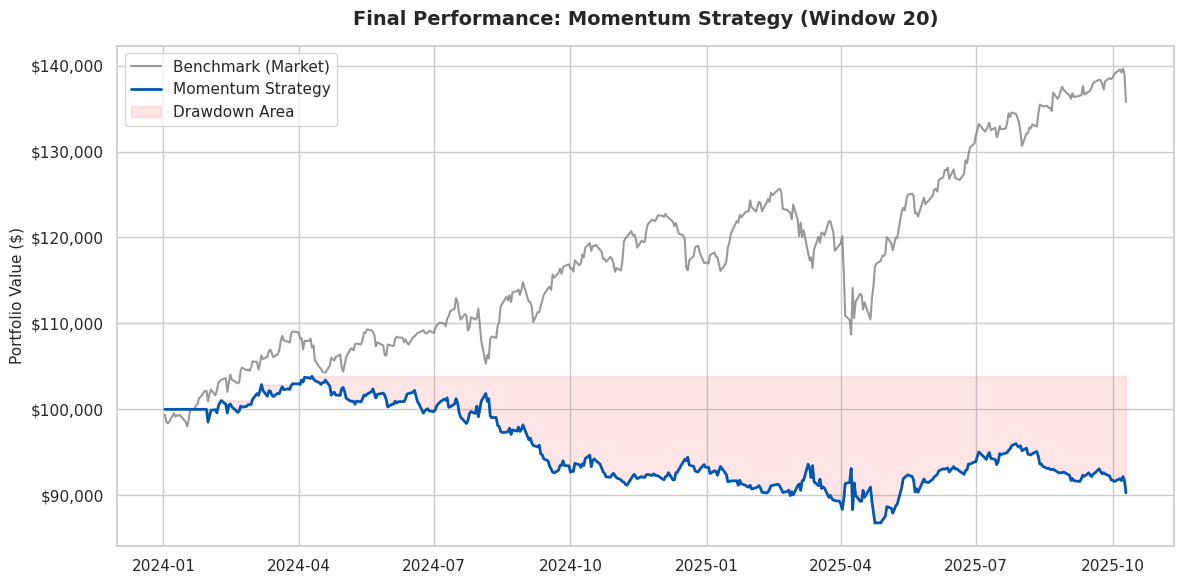

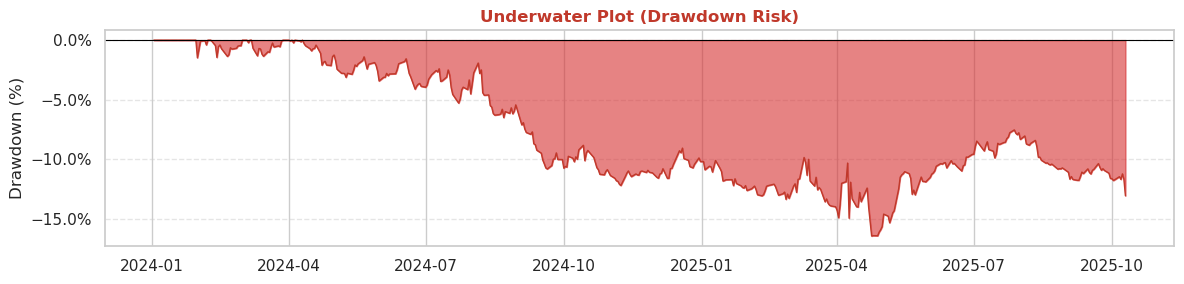

In [21]:
# Tạo Benchmark (Giả sử mua đều thị trường và nắm giữ)
simple_rets = np.exp(test_df['Log Return']) - 1
bench_simple_ret = simple_rets.mean(axis=1)
bench_equity = (1 + bench_simple_ret).cumprod() * tester.initial_capital

# Vẽ biểu đồ so sánh
viz.plot_strategy_vs_benchmark(
    equity_test, 
    bench_equity, 
    title=f"Final Performance: Momentum Strategy (Window {best_w})"
)

# (Tuỳ chọn) Vẽ biểu đồ rủi ro (Underwater)
viz.plot_underwater(equity_test)

## **3.2. Mean Reversion Strategy**

In [22]:
mean_reversion = MeanReversionStrategy(df)
mean_reversion_signals = mean_reversion.generate_signals()

In [23]:
viz = Visualizer()

### **Backtest**

In [24]:
tester = Backtester(df, initial_capital=config.initial_capital, transaction_cost=config.transaction_cost)
train_df, val_df, test_df = tester.split_data(train_end=config.train_end, val_end=config.val_end)

In [25]:
# Train set
eq_train, m_train = tester.run_and_evaluate(train_df, MeanReversionStrategy, "Mean Reversion (Train)")
display(m_train)

,Total Return,Sharpe Ratio,Max Drawdown,Final Capital
Mean Reversion (Train),262.02%,0.7,-27.06%,"$362,016"


In [26]:
# Validation set - Hyperparameter Tuning
mr_params = config.mean_reversion_params

mr_results = tester.optimize_grid_search(val_df, MeanReversionStrategy, mr_params)

best = mr_results.iloc[0]
display(best.to_frame().T)
# viz.plot_tuning_heatmap(tuning_res, metric='Sharpe Ratio')

,Total Return,Sharpe Ratio,Max Drawdown,Final Capital,window,std_dev
8,66.90%,0.88,-24.91%,"$166,904",50,2.5


In [27]:
best_w = int(best['window'])
best_std = best['std_dev']
print(f"BEST PARAMS: Window={best_w}, Std Dev={best_std}")

# Chạy Backtest trên tập Test với tham số tối ưu
equity_test, metrics_test = tester.run_and_evaluate(
    test_df, MeanReversionStrategy, 
    label=f"Mean Reversion - Test (W{best_w}-SD{best_std})", 
    window=best_w, std_dev=best_std
)

display(metrics_test)

BEST PARAMS: Window=50, Std Dev=2.5


,Total Return,Sharpe Ratio,Max Drawdown,Final Capital
Mean Reversion - Test (W50-SD2.5),66.25%,1.63,-13.72%,"$166,250"


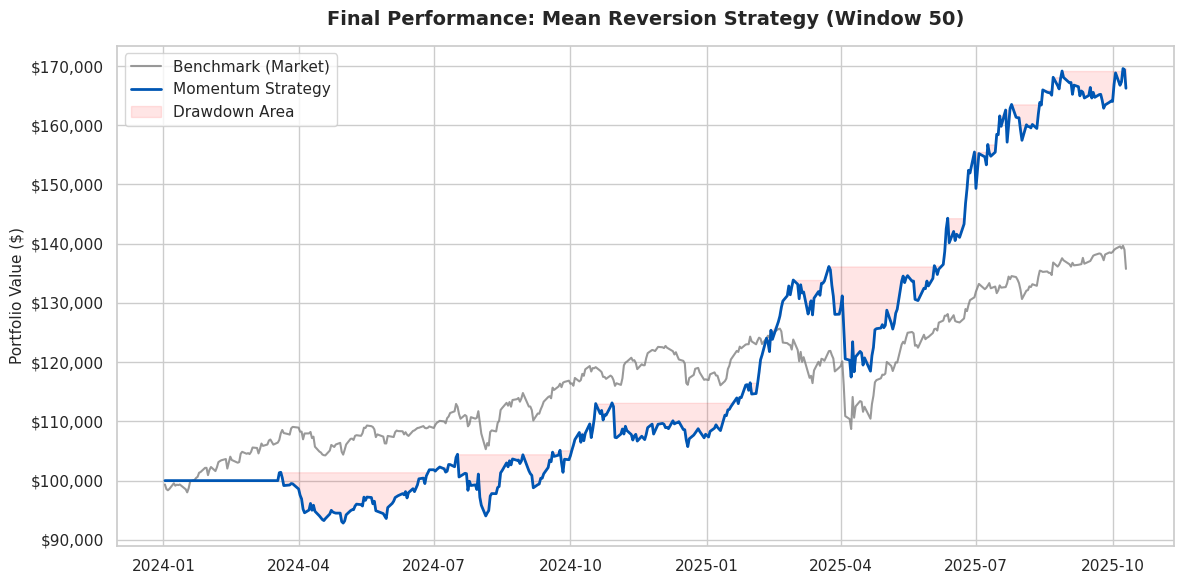

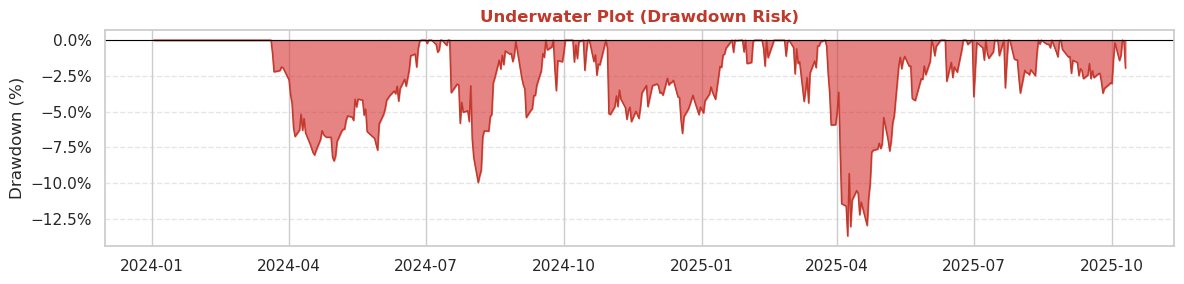

In [28]:
# Tạo Benchmark (Giả sử mua đều thị trường và nắm giữ)
# Cách tính: Trung bình Log Return của các mã -> Lũy kế
# Tạo Benchmark (Giả sử mua đều thị trường và nắm giữ)
simple_rets = np.exp(test_df['Log Return']) - 1
bench_simple_ret = simple_rets.mean(axis=1)
bench_equity = (1 + bench_simple_ret).cumprod() * tester.initial_capital

# Vẽ biểu đồ so sánh
viz.plot_strategy_vs_benchmark(
    equity_test, 
    bench_equity, 
    title=f"Final Performance: Mean Reversion Strategy (Window {best_w})"
)
# (Tuỳ chọn) Vẽ biểu đồ rủi ro (Underwater)
viz.plot_underwater(equity_test)